# 🗺️ Peta IPM Jawa Timur — Visualisasi Statistik Geospatial
**Topik :** Indeks Pembangunan Manusia (IPM) per Kabupaten/Kota Jawa Timur  
**Teknik :** HeatMap · CircleMarker · Choropleth · Animasi Timeline  
**Sumber Data :** [BPS Jawa Timur — WebAPI](https://webapi.bps.go.id/developer/)  
**GeoJSON :** [ardian28/GeoJson-Indonesia-38-Provinsi](https://github.com/ardian28/GeoJson-Indonesia-38-Provinsi)  

---

## 📋 Alur Kerja
```
1. Install & Import Library
2. Ambil Data IPM dari BPS API
3. Parsing & Cleaning Data
4. Visualisasi Grafik Standar (Seaborn)
5. HeatMap Folium
6. CircleMarker + Tooltip Info
7. Choropleth Map (pakai GeoJSON batas wilayah)
8. Animasi Timeline Multi-Tahun
9. Export ke HTML
```

# 1. 📦 Install & Import Library

In [ ]:
# Install library yang dibutuhkan (jalankan sekali)
!pip install folium requests pandas seaborn matplotlib -q
!pip install branca -q  # dependency folium untuk colormap

# 2. 📂 Import Data IPM dari CSV

> **Format:** 5 file CSV terpisah per tahun (2021–2025)  
> Setiap file memiliki 2 kolom: `Kabupaten/Kota` dan `Indeks Pembangunan Manusia`  

Nama file contoh:
```
Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2025.csv
Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2024.csv
Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2023.csv
Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2022.csv
Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2021.csv
```

Upload kelima file CSV di cell berikut.

In [ ]:
# ── UPLOAD 5 FILE CSV (SATU PER TAHUN) ────────────────────────────────────
import io, os, re
import pandas as pd

# === OPSI 1: Upload di Google Colab ===
try:
    from google.colab import files as colab_files
    print('📂 Upload 5 file CSV IPM (2021–2025)...')
    uploaded = colab_files.upload()
    file_dict = {name: io.BytesIO(data) for name, data in uploaded.items()}
except ImportError:
    # === OPSI 2: Baca dari folder lokal (Jupyter biasa) ===
    CSV_FOLDER = '.'  # ← ganti dengan path folder CSV kamu
    file_dict = {}
    for f in os.listdir(CSV_FOLDER):
        if f.endswith('.csv') and 'Indeks Pembangunan Manusia' in f:
            file_dict[f] = os.path.join(CSV_FOLDER, f)

# ── Baca & gabungkan semua file ────────────────────────────────────────────
df_list = []
for filename, source in file_dict.items():
    # Ekstrak tahun dari nama file
    match = re.search(r'(\d{4})', filename)
    if not match:
        print(f'⚠️  Tidak bisa deteksi tahun dari: {filename}, skip.')
        continue
    tahun = int(match.group(1))

    # Baca CSV
    if isinstance(source, io.BytesIO):
        df_temp = pd.read_csv(source)
    else:
        df_temp = pd.read_csv(source)

    # Rename kolom ke format internal
    df_temp = df_temp.rename(columns={
        'Kabupaten/Kota': 'Kab_Kota',
        'Indeks Pembangunan Manusia': 'IPM'
    })
    df_temp['Tahun'] = tahun
    df_list.append(df_temp)
    print(f'✅ {filename} → Tahun {tahun}, {len(df_temp)} baris')

if df_list:
    df_raw = pd.concat(df_list, ignore_index=True)
    print(f'\n📊 Total baris gabungan: {len(df_raw)}')
    print(f'   Kolom: {list(df_raw.columns)}')
    display(df_raw.head())
else:
    print('❌ Tidak ada file yang diproses.')

📂 Upload 5 file CSV IPM (2021–2025)...


Saving Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2021.csv to Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2021 (2).csv
Saving Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2022.csv to Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2022 (2).csv
Saving Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2023.csv to Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2023 (2).csv
Saving Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2024.csv to Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2024 (2).csv
Saving Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2025.csv to Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2025 (2).csv
✅ Indeks Pembangunan Manusia Menurut Kabupaten_Kota di Provinsi Jawa Timur, 2021 (2).csv → Tahun 202

,Kab_Kota,IPM,Tahun
0,Pacitan,69.45,2021
1,Ponorogo,71.81,2021
2,Trenggalek,70.40,2021
3,Tulungagung,73.29,2021
4,Blitar,71.48,2021


# 3. 🧹 Parsing & Cleaning Data

In [ ]:
# ── KOORDINAT GPS KABUPATEN/KOTA JAWA TIMUR ───────────────────────────────
# Sumber: cahyadsn/wilayah & OpenStreetMap
geo_coords = {
    'Pacitan':      [-8.2104, 111.0877], 'Ponorogo':     [-7.8677, 111.4665],
    'Trenggalek':   [-8.1706, 111.7139], 'Tulungagung':  [-8.0658, 111.9023],
    'Blitar':       [-8.0953, 112.1685], 'Kediri':       [-7.9480, 112.0178],
    'Malang':       [-8.1320, 112.5714], 'Lumajang':     [-8.1333, 113.2226],
    'Jember':       [-8.1724, 113.7026], 'Banyuwangi':   [-8.2192, 114.3691],
    'Bondowoso':    [-7.9165, 113.8222], 'Situbondo':    [-7.7058, 114.0136],
    'Probolinggo':  [-7.7543, 113.2159], 'Pasuruan':     [-7.6456, 112.9023],
    'Sidoarjo':     [-7.4458, 112.7181], 'Mojokerto':    [-7.4712, 111.5255],
    'Jombang':      [-7.5461, 112.2384], 'Nganjuk':      [-7.6048, 111.9007],
    'Madiun':       [-7.6298, 111.5236], 'Magetan':      [-7.6435, 111.3285],
    'Ngawi':        [-7.4065, 111.4459], 'Bojonegoro':   [-7.1514, 111.8815],
    'Tuban':        [-6.8997, 112.0508], 'Lamongan':     [-7.1170, 112.4155],
    'Gresik':       [-7.1569, 112.6550], 'Bangkalan':    [-7.0452, 112.7442],
    'Sampang':      [-7.1866, 113.2458], 'Pamekasan':    [-7.1575, 113.4711],
    'Sumenep':      [-6.9741, 113.8608],
    'Kota Kediri':  [-7.8166, 112.0114], 'Kota Blitar':  [-8.0953, 112.1615],
    'Kota Malang':  [-7.9797, 112.6304], 'Kota Probolinggo': [-7.7550, 113.2149],
    'Kota Pasuruan':[-7.6450, 112.9072], 'Kota Mojokerto':   [-7.4700, 112.4332],
    'Kota Madiun':  [-7.6298, 111.5179], 'Kota Surabaya':    [-7.2575, 112.7521],
    'Kota Batu':    [-7.8695, 112.5267],
}

print(f'✅ Koordinat tersedia untuk {len(geo_coords)} Kab/Kota')

✅ Koordinat tersedia untuk 38 Kab/Kota


In [ ]:
# ── CLEANING & MERGE DENGAN KOORDINAT ─────────────────────────────────────
import re

def clean_number(val):
    """Bersihkan string angka BPS ke float."""
    if val is None or str(val).strip() in ('', '-', 'NA', 'na'):
        return None
    cleaned = re.sub(r'[^0-9,.]', '', str(val))
    cleaned = cleaned.replace(',', '.')
    try:
        return float(cleaned)
    except:
        return None

# Bersihkan kolom IPM
df_raw['IPM'] = df_raw['IPM'].apply(clean_number)

# Bersihkan nama Kab/Kota (hapus spasi ekstra, strip)
df_raw['Kab_Kota'] = df_raw['Kab_Kota'].astype(str).str.strip()

# Tambahkan koordinat
df_raw['Lat'] = df_raw['Kab_Kota'].map(lambda x: geo_coords.get(x, [None, None])[0])
# Tetap gunakan x asal (string) untuk lookup koordinat
df_raw['Lon'] = df_raw['Kab_Kota'].map(lambda x: geo_coords.get(x, [None, None])[1])

# Filter hanya yang punya koordinat & IPM valid
df_all = df_raw.dropna(subset=['IPM', 'Lat', 'Lon']).copy()
df_all['Tahun'] = df_all['Tahun'].astype(int)

# Cek nama yang tidak cocok dengan koordinat
no_match = set(df_raw['Kab_Kota'].unique()) - set(geo_coords.keys())
if no_match:
    print(f'⚠️  {len(no_match)} nama tidak cocok dengan koordinat:')
    # Fix: Ensure all items are strings for sorting
    for nm in sorted([str(x) for x in no_match]):
        if nm != 'nan':
            print(f'   - "{nm}"')
    print('   Sesuaikan nama di CSV agar sama persis dengan daftar geo_coords.')
    print(f'   Daftar nama yang dikenali: {sorted(geo_coords.keys())}')

TAHUN_LIST = sorted(df_all['Tahun'].unique())
print(f'\n✅ Total baris data valid: {len(df_all)}')
print(f'   Tahun tersedia: {TAHUN_LIST}')
print(f'   Kab/Kota tersedia: {df_all["Kab_Kota"].nunique()}')
print()
print(df_all.head(10).to_string(index=False))

⚠️  4 nama tidak cocok dengan koordinat:
   - "Catatan"
   - "Indeks Pembangunan Manusia (IPM) 2020-2023 dihitung menggunakan Umur Harapan Hidup saat Lahir (UHH) hasil Long Form SP2020 (LF SP2020). IPM 2023 yang menggunakan UHH hasil SP2010 masih tersedia dan dapat diakses pada website BPS (www.bps.go.id)/<i>The 2020–2023 Human Development Index (HDI) was calculated using the Life Expectancy at Birth based on the Long Form 2020 Population Census. The 2023 HDI data using life expectancy based on the 2010 Population Census are still available at the BPS website (www.bps.go.id)</i>"
   - "Jawa Timur"
   Sesuaikan nama di CSV agar sama persis dengan daftar geo_coords.
   Daftar nama yang dikenali: ['Bangkalan', 'Banyuwangi', 'Blitar', 'Bojonegoro', 'Bondowoso', 'Gresik', 'Jember', 'Jombang', 'Kediri', 'Kota Batu', 'Kota Blitar', 'Kota Kediri', 'Kota Madiun', 'Kota Malang', 'Kota Mojokerto', 'Kota Pasuruan', 'Kota Probolinggo', 'Kota Surabaya', 'Lamongan', 'Lumajang', 'Madiun', 'Magetan', '

# 4. 📊 Visualisasi Grafik Standar (Seaborn)

/tmp/ipykernel_2074/989455051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y='Kab_Kota', x='IPM', palette='Blues_r', ax=axes[0])
/tmp/ipykernel_2074/989455051.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot10, y='Kab_Kota', x='IPM', palette='Reds_r', ax=axes[1])


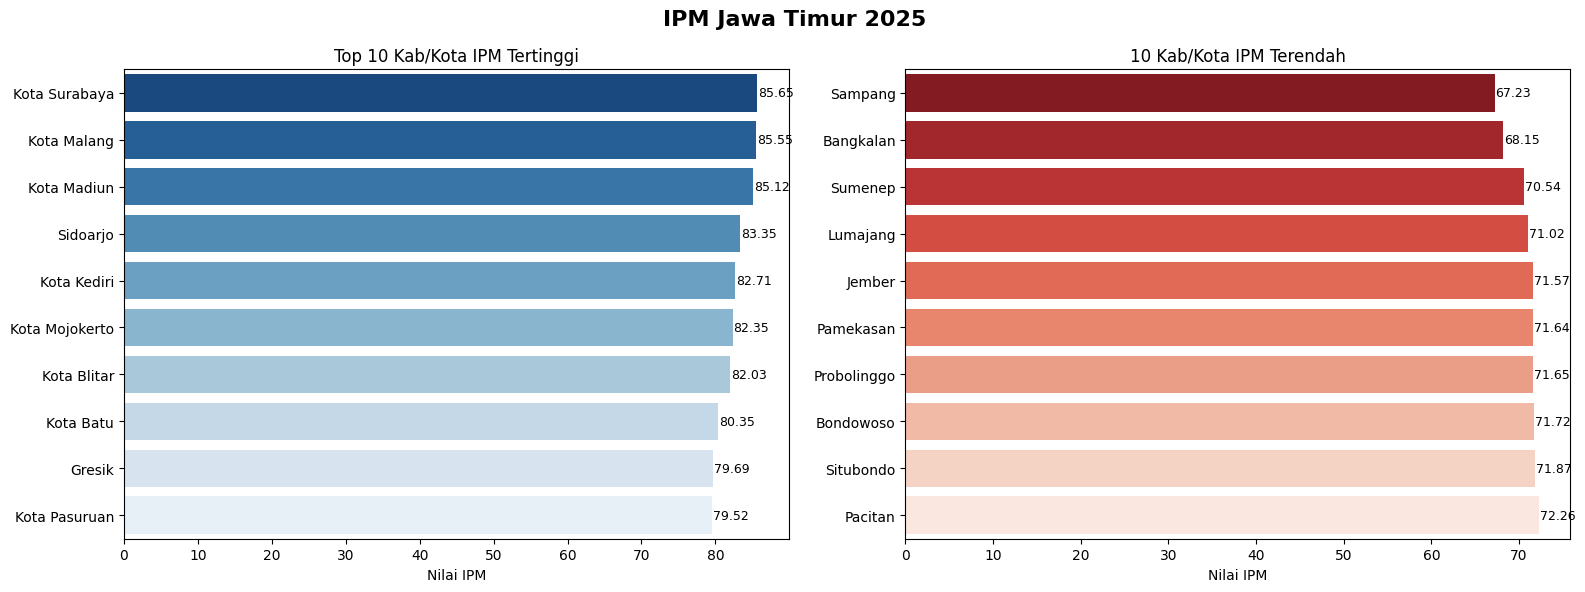

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── GRAFIK 1: Top 10 Kab/Kota dengan IPM Tertinggi (Tahun Terbaru) ────────
if not df_all.empty and 'Tahun' in df_all.columns:
    tahun_terbaru = df_all['Tahun'].max()
    df_latest = df_all[df_all['Tahun'] == tahun_terbaru].sort_values('IPM', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'IPM Jawa Timur {tahun_terbaru}', fontsize=16, fontweight='bold')

    # Bar chart Top 10
    top10 = df_latest.head(10)
    sns.barplot(data=top10, y='Kab_Kota', x='IPM', palette='Blues_r', ax=axes[0])
    axes[0].set_title('Top 10 Kab/Kota IPM Tertinggi')
    axes[0].set_xlabel('Nilai IPM')
    axes[0].set_ylabel('')
    for i, v in enumerate(top10['IPM']):
        axes[0].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

    # Bar chart Bottom 10
    bot10 = df_latest.tail(10).sort_values('IPM')
    sns.barplot(data=bot10, y='Kab_Kota', x='IPM', palette='Reds_r', ax=axes[1])
    axes[1].set_title('10 Kab/Kota IPM Terendah')
    axes[1].set_xlabel('Nilai IPM')
    axes[1].set_ylabel('')
    for i, v in enumerate(bot10['IPM']):
        axes[1].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Tidak ada data. Pastikan CSV berhasil di-upload dan nama Kab/Kota cocok.')

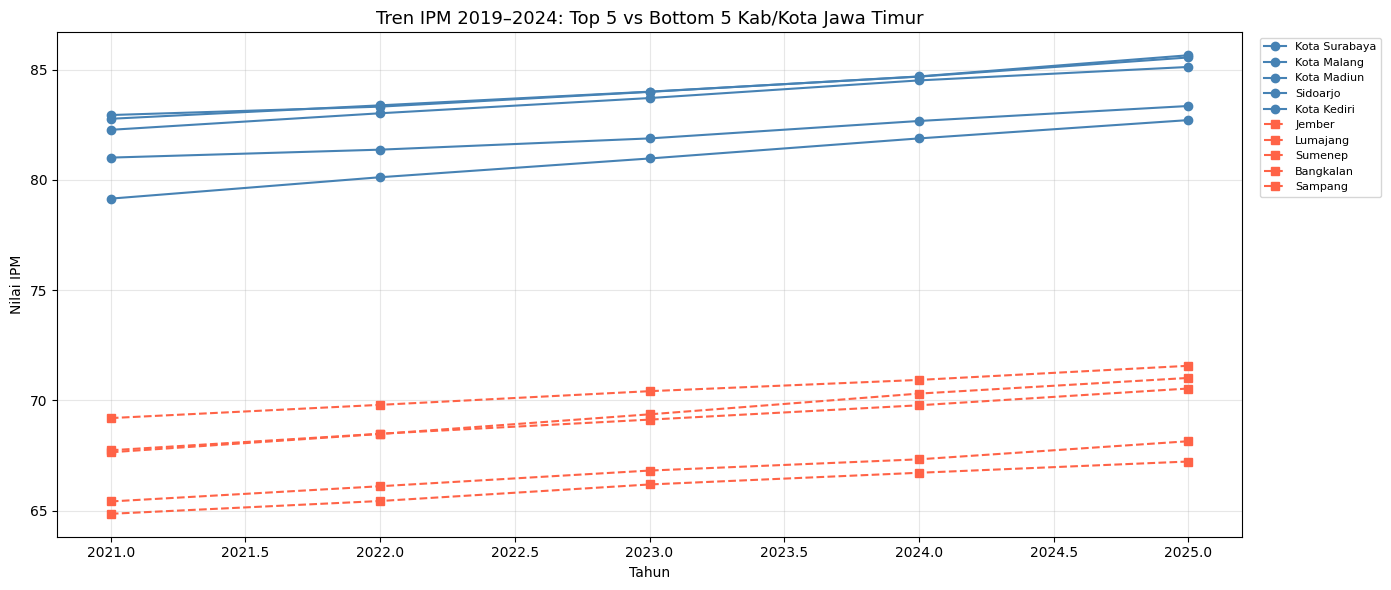

In [ ]:
# ── GRAFIK 2: Tren IPM Multi-Tahun (Top 5 & Bottom 5) ────────────────────
top5_names  = df_latest.head(5)['Kab_Kota'].tolist()
bot5_names  = df_latest.tail(5)['Kab_Kota'].tolist()
selected    = top5_names + bot5_names

df_trend = df_all[df_all['Kab_Kota'].isin(selected)]

fig, ax = plt.subplots(figsize=(14, 6))
for name in selected:
    subset = df_trend[df_trend['Kab_Kota'] == name].sort_values('Tahun')
    style  = '-o' if name in top5_names else '--s'
    color  = 'steelblue' if name in top5_names else 'tomato'
    ax.plot(subset['Tahun'], subset['IPM'], style, color=color, label=name, linewidth=1.5)

ax.set_title('Tren IPM 2019–2024: Top 5 vs Bottom 5 Kab/Kota Jawa Timur', fontsize=13)
ax.set_xlabel('Tahun')
ax.set_ylabel('Nilai IPM')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2074/1911049296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='Tahun', y='IPM', palette='viridis', ax=ax)


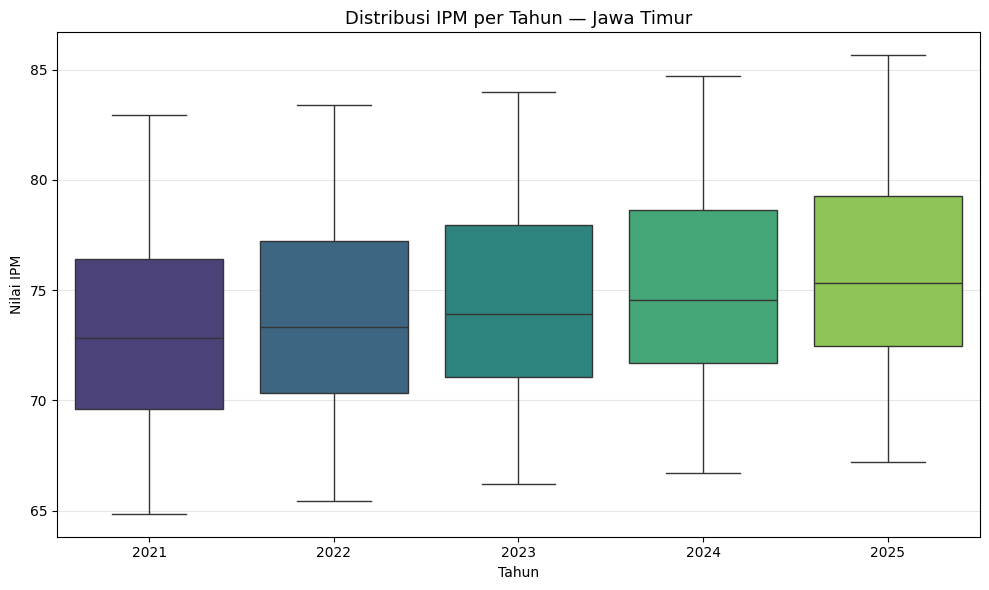

In [ ]:
# ── GRAFIK 3: Distribusi IPM per Tahun (Boxplot) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_all, x='Tahun', y='IPM', palette='viridis', ax=ax)
ax.set_title('Distribusi IPM per Tahun — Jawa Timur', fontsize=13)
ax.set_xlabel('Tahun')
ax.set_ylabel('Nilai IPM')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 5. 🌡️ HeatMap Folium — Intensitas IPM per Kab/Kota

In [ ]:
import folium
from folium.plugins import HeatMap

df_map = df_all[df_all['Tahun'] == tahun_terbaru].dropna(subset=['IPM', 'Lat', 'Lon'])

# ── BUAT PETA DASAR ────────────────────────────────────────────────────────
m_heat = folium.Map(
    location=[-7.75, 112.7],
    zoom_start=8,
    tiles='CartoDB positron'
)

# ── DATA UNTUK HEATMAP [lat, lon, weight] ─────────────────────────────────
heat_data = df_map[['Lat', 'Lon', 'IPM']].values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=30,
    blur=20,
    gradient={0.2: 'blue', 0.5: 'lime', 0.8: 'orange', 1.0: 'red'},
    name='HeatMap IPM'
).add_to(m_heat)

# ── JUDUL PETA ─────────────────────────────────────────────────────────────
title_html = f'''
    <div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
                z-index:9999; background:white; padding:10px 20px;
                border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,0.2);
                font-family:Arial; font-size:14px; font-weight:bold;">
        ⚔  HeatMap IPM Jawa Timur {tahun_terbaru}
    </div>'''
m_heat.get_root().html.add_child(folium.Element(title_html))

m_heat

# 6. 📍 CircleMarker + Tooltip Lengkap per Kab/Kota

In [ ]:
import branca.colormap as cm

ipm_min = df_map['IPM'].min()
ipm_max = df_map['IPM'].max()

# Colormap: merah (rendah) → hijau (tinggi)
colormap = cm.LinearColormap(
    colors=['#e74c3c', '#f39c12', '#2ecc71'],
    vmin=ipm_min, vmax=ipm_max,
    caption=f'Nilai IPM {tahun_terbaru}'
)

m_circle = folium.Map(location=[-7.75, 112.7], zoom_start=8, tiles='CartoDB positron')
colormap.add_to(m_circle)

for _, row in df_map.iterrows():
    color = colormap(row['IPM'])

    tooltip_text = (
        f"<b>{row['Kab_Kota']}</b><br>"
        f"IPM: <b>{row['IPM']:.2f}</b>"
    )

    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=max(5, (row['IPM'] - ipm_min) / (ipm_max - ipm_min) * 18 + 5),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        tooltip=folium.Tooltip(tooltip_text, sticky=True),
    ).add_to(m_circle)

title_html = f'''
    <div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
                z-index:9999; background:white; padding:10px 20px;
                border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,0.2);
                font-family:Arial; font-size:14px; font-weight:bold;">
           Circle Map IPM Jawa Timur {tahun_terbaru} — Ukuran & Warna = Nilai IPM
    </div>'''
m_circle.get_root().html.add_child(folium.Element(title_html))

m_circle

# 7. 🗺️ Choropleth Map (Batas Wilayah Resmi)

Choropleth menggunakan **batas wilayah GeoJSON** sehingga setiap kab/kota ditampilkan
sebagai poligon berwarna, bukan hanya titik koordinat.

> **Download GeoJSON Jatim:**  
> https://github.com/ardian28/GeoJson-Indonesia-38-Provinsi  
> Cari file `jawa_timur_kabupaten.geojson` atau sesuai path repo.

# 8. 🎬 Animasi Timeline Multi-Tahun

Menggunakan **`TimestampedGeoJson`** dari `folium.plugins` untuk membuat
slider animasi yang menunjukkan perubahan IPM per tahun di setiap kab/kota.

In [ ]:
# ── BANGUN GEOJSON FEATURES DENGAN TIMESTAMP ──────────────────────────────
ipm_min_all = df_all['IPM'].min()
ipm_max_all = df_all['IPM'].max()

def ipm_to_color(ipm):
    """Konversi nilai IPM ke warna hex (merah → kuning → hijau)."""
    ratio = (ipm - ipm_min_all) / (ipm_max_all - ipm_min_all + 1e-9)
    if ratio < 0.5:
        r, g, b = 1, ratio * 2, 0
    else:
        r, g, b = 1 - (ratio - 0.5) * 2, 1, 0
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

features = []
for _, row in df_all.dropna(subset=['IPM']).iterrows():
    radius   = max(4, (row['IPM'] - ipm_min_all) / (ipm_max_all - ipm_min_all + 1e-9) * 20 + 4)
    color    = ipm_to_color(row['IPM'])
    features.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [row['Lon'], row['Lat']]  # GeoJSON: [lon, lat]
        },
        'properties': {
            'time':   f"{int(row['Tahun'])}-01-01",
            'popup':  f"<b>{row['Kab_Kota']}</b><br>IPM {int(row['Tahun'])}: {row['IPM']:.2f}",
            'style':  {
                'color':       color,
                'fillColor':   color,
                'fillOpacity': 0.8,
                'weight':      1,
                'radius':      radius
            },
            'icon':   'circle',
            'iconstyle': {
                'fillColor':   color,
                'fillOpacity': 0.8,
                'stroke':      True,
                'radius':      radius
            }
        }
    })

print(f'✅ {len(features)} features disiapkan untuk animasi')

✅ 190 features disiapkan untuk animasi


In [ ]:
# ── BUAT PETA ANIMASI ─────────────────────────────────────────────────────
import folium
from folium.plugins import TimestampedGeoJson

m_anim = folium.Map(location=[-7.75, 112.7], zoom_start=8, tiles='CartoDB positron')

TimestampedGeoJson(
    data={'type': 'FeatureCollection', 'features': features},
    period='P1Y',         # interval: 1 tahun
    duration='P1Y',       # durasi tampil tiap frame
    auto_play=False,
    loop=True,
    max_speed=1,
    loop_button=True,
    date_options='YYYY',
    time_slider_drag_update=True,
).add_to(m_anim)

# Legend warna manual
legend_html = '''
    <div style="position:fixed; bottom:30px; left:20px; z-index:9999;
                background:white; padding:12px 16px; border-radius:8px;
                box-shadow:0 2px 8px rgba(0,0,0,0.2); font-family:Arial; font-size:12px;">
        <b>Nilai IPM</b><br>
        <span style="color:#e74c3c">●</span> Rendah<br>
        <span style="color:#f1c40f">●</span> Sedang<br>
        <span style="color:#2ecc71">●</span> Tinggi
    </div>'''
m_anim.get_root().html.add_child(folium.Element(legend_html))

title_html = '''
    <div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
                z-index:9999; background:white; padding:10px 20px;
                border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,0.2);
                font-family:Arial; font-size:14px; font-weight:bold;">
        🎬 Animasi IPM Jawa Timur 2019–2024 — Tekan ▶ untuk Putar
    </div>'''
m_anim.get_root().html.add_child(folium.Element(title_html))

m_anim

# 9. 💾 Export Semua Peta ke HTML

In [ ]:
from google.colab import files

# Simpan semua peta sebagai file HTML
maps = {
    'peta_heatmap_IPM.html':    m_heat,
    'peta_circlemarker_IPM.html': m_circle,
    'peta_choropleth_IPM.html': m_choro,
    'peta_animasi_IPM.html':    m_anim,
}

for filename, peta in maps.items():
    peta.save(filename)
    print(f'✅ Tersimpan: {filename}')

print('\n📥 Mengunduh semua file...')
for filename in maps:
    files.download(filename)

✅ Tersimpan: peta_heatmap_IPM.html
✅ Tersimpan: peta_circlemarker_IPM.html
✅ Tersimpan: peta_choropleth_IPM.html
✅ Tersimpan: peta_animasi_IPM.html

📥 Mengunduh semua file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# 📝 Catatan Kustomisasi

| Langkah | Yang Perlu Diubah |
|---|---|
| **API Key** | Ganti `API_KEY` di Section 2 |
| **ID Tabel** | Ganti `ID_TABEL_IPM` dengan ID tabel dari URL BPS |
| **Key Variabel** | Uncomment baris debug di `parse_ipm_data()` lalu lihat key yang tersedia |
| **GeoJSON key** | Cek `geojson_jatim['features'][0]['properties']` lalu sesuaikan `key_on` |
| **Provinsi lain** | Ganti `WILAYAH_JATIM` dengan kode wilayah target + update `geo_coords` |
| **Topik lain** | Ganti `ID_TABEL_IPM` dengan ID tabel kemiskinan/stunting/pengangguran |

## 🔗 Sumber Referensi
- **BPS API:** https://webapi.bps.go.id/developer/
- **BPS Jatim Data:** https://jatim.bps.go.id
- **GeoJSON Indonesia:** https://github.com/ardian28/GeoJson-Indonesia-38-Provinsi
- **Koordinat Kab/Kota:** https://github.com/cahyadsn/wilayah
- **Satu Data Indonesia:** https://data.go.id
